# Shape Detection

Next we will detect simple shapes by finding the contour and approximating the polygons.

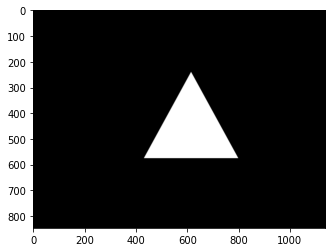

In [1]:
# import the necessary packages
#import imutils
import matplotlib.pyplot as plt
import cv2
 
# Business as usual: read image, change the colorspace and visualise it
image = cv2.imread('images/triangle.png')

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')

Next we smooth the image by blurring, in order to remove high frequent noise. Implementation details and further information can be found on the OpenCV website: https://opencv-python-tutroals.readthedocs.io/en/latest/py_tutorials/py_imgproc/py_filtering/py_filtering.html . We will be using the `cv2.GaussianBlur()` function. 

Blurring images is a common step in computer vision applications before extracting further features!

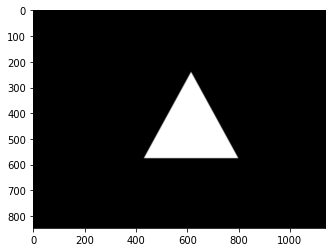

In [2]:
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

plt.imshow(blurred, cmap='gray')

Next we create a binary image (mask), splitting background from objects. 

Similar to before, we could use a color segmentation to generate our mask. As the background is simply black in our case, we will be using the `cv2.threshold()` function to generate the mask. Note that there are different ways of generating the binary image. 

As usual, we can visualise information about the `threshold()` function:

In [3]:
help(cv2.threshold)

Help on built-in function threshold:

threshold(...)
    threshold(src, thresh, maxval, type[, dst]) -> retval, dst
    .   @brief Applies a fixed-level threshold to each array element.
    .   
    .   The function applies fixed-level thresholding to a multiple-channel array. The function is typically
    .   used to get a bi-level (binary) image out of a grayscale image ( #compare could be also used for
    .   this purpose) or for removing a noise, that is, filtering out pixels with too small or too large
    .   values. There are several types of thresholding supported by the function. They are determined by
    .   type parameter.
    .   
    .   Also, the special values #THRESH_OTSU or #THRESH_TRIANGLE may be combined with one of the
    .   above values. In these cases, the function determines the optimal threshold value using the Otsu's
    .   or Triangle algorithm and uses it instead of the specified thresh.
    .   
    .   @note Currently, the Otsu's and Triangle methods a

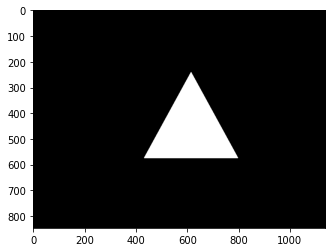

In [4]:
thresh = cv2.threshold(blurred, 60, 255, cv2.THRESH_BINARY)[1]

plt.imshow(thresh, cmap='gray')

Now lets use this mask to find the contours using `cv2.findContours()`. It returns a list of outlines for each white area in our image. `cv2.drawContours()` helps us then to draw the contours onto our image by looping through each entry in our `cnts`-list.

In [5]:
help(cv2.findContours)

Help on built-in function findContours:

findContours(...)
    findContours(image, mode, method[, contours[, hierarchy[, offset]]]) -> contours, hierarchy
    .   @brief Finds contours in a binary image.
    .   
    .   The function retrieves contours from the binary image using the algorithm @cite Suzuki85 . The contours
    .   are a useful tool for shape analysis and object detection and recognition. See squares.cpp in the
    .   OpenCV sample directory.
    .   @note Since opencv 3.2 source image is not modified by this function.
    .   
    .   @param image Source, an 8-bit single-channel image. Non-zero pixels are treated as 1's. Zero
    .   pixels remain 0's, so the image is treated as binary . You can use #compare, #inRange, #threshold ,
    .   #adaptiveThreshold, #Canny, and others to create a binary image out of a grayscale or color one.
    .   If mode equals to #RETR_CCOMP or #RETR_FLOODFILL, the input can also be a 32-bit integer image of labels (CV_32SC1).
    .   @p

In [6]:
cnts = cv2.findContours(thresh.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)[0]; cnts

[array([[[613, 241]],
 
        [[612, 242]],
 
        [[612, 243]],
 
        ...,
 
        [[615, 243]],
 
        [[615, 242]],
 
        [[614, 241]]], dtype=int32)]

In [7]:
help(cv2.drawContours)

Help on built-in function drawContours:

drawContours(...)
    drawContours(image, contours, contourIdx, color[, thickness[, lineType[, hierarchy[, maxLevel[, offset]]]]]) -> image
    .   @brief Draws contours outlines or filled contours.
    .   
    .   The function draws contour outlines in the image if \f$\texttt{thickness} \ge 0\f$ or fills the area
    .   bounded by the contours if \f$\texttt{thickness}<0\f$ . The example below shows how to retrieve
    .   connected components from the binary image and label them: :
    .   @include snippets/imgproc_drawContours.cpp
    .   
    .   @param image Destination image.
    .   @param contours All the input contours. Each contour is stored as a point vector.
    .   @param contourIdx Parameter indicating a contour to draw. If it is negative, all the contours are drawn.
    .   @param color Color of the contours.
    .   @param thickness Thickness of lines the contours are drawn with. If it is negative (for example,
    .   thickness

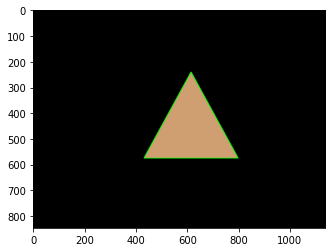

In [8]:
contour_image = image.copy()

cv2.drawContours(contour_image, [cnts[0]], -1, (0, 255, 0), 2)

#plot the image
plt.imshow(contour_image)

So far, we have detected the edge of our shape. This information does not allow us to classify the shape type though. 
In order to be able to classify a shape, we need to approximate the contours. OpenCV again comes with a function, that allows us to do so. 
`cv2.approxPolyDP()` approximates our shape using polygonal curve(s). The Precision can be set using the input parameters.

In [9]:
help(cv2.approxPolyDP)

Help on built-in function approxPolyDP:

approxPolyDP(...)
    approxPolyDP(curve, epsilon, closed[, approxCurve]) -> approxCurve
    .   @brief Approximates a polygonal curve(s) with the specified precision.
    .   
    .   The function cv::approxPolyDP approximates a curve or a polygon with another curve/polygon with less
    .   vertices so that the distance between them is less or equal to the specified precision. It uses the
    .   Douglas-Peucker algorithm <http://en.wikipedia.org/wiki/Ramer-Douglas-Peucker_algorithm>
    .   
    .   @param curve Input vector of a 2D point stored in std::vector or Mat
    .   @param approxCurve Result of the approximation. The type should match the type of the input curve.
    .   @param epsilon Parameter specifying the approximation accuracy. This is the maximum distance
    .   between the original curve and its approximation.
    .   @param closed If true, the approximated curve is closed (its first and last vertices are
    .   connected).

We will now create our own function that detects a shape for a given contour. This allows us to reuse the code for later robotics applications. 

In [10]:
def detect_shape(contour):
    arc = cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, 0.04 * arc , True)
    return len(approx)

In [11]:
cnts

[array([[[613, 241]],
 
        [[612, 242]],
 
        [[612, 243]],
 
        ...,
 
        [[615, 243]],
 
        [[615, 242]],
 
        [[614, 241]]], dtype=int32)]

Let's see how it performs on our image:

In [12]:
detect_shape(cnts[0])

3

Lets put all of this together in a small script to analyze other images:

Detected polygon with 4 corners.


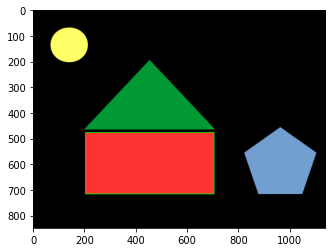

In [13]:
image = cv2.imread('images/shapes.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
contour_image = image.copy()
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
blurred = cv2.GaussianBlur(gray,(5,5), 0)
thresh = cv2.threshold(blurred, 60, 255, cv2.THRESH_BINARY)[1]
cnts = cv2.findContours(thresh.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)[0]
shape = detect_shape(cnts[0])

#cv2.drawContours(contour_image, [cnts[0]], -1, (0, red,  60, 255, cv2.THRESH_BINARY)[1], 255, 0)
cv2.drawContours(contour_image, [cnts[0]], -1, (0, 255, 0), 2)
plt.imshow(contour_image)
print("Detected polygon with " + str(shape) + " corners.")

# Multiple Shapes in a single image

Firstly, we load the image, convert to grayscale, blur it, create a binary image using the threshold function and find the contours. Same as before.

In [14]:
image = cv2.imread('images/shapes.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
contour_image = image.copy()
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
blurred = cv2.GaussianBlur(gray,(5,5), 0)
thresh = cv2.threshold(blurred, 60, 255, cv2.THRESH_BINARY)[1]
cnts = cv2.findContours(thresh.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)[0]

Compared to our previous script, `cnts` is now a list containing multiple contour instances. We can check the length of this list using the `len()` function.

In [15]:
len(cnts)

4

Using this knowledge we can now loop through these contours:

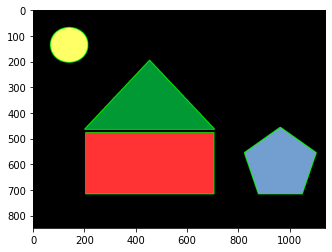

In [16]:
for c in cnts: 
    shape = detect_shape(cnts[0])
    cv2.drawContours(contour_image, [c], -1, (0, 255, 0), 2)

plt.imshow(contour_image)

# Optional

Using what we have learned so far, can you create an algorithm that detects the red rectangle in `images/shapes.png`? 